## test new histograms locally

In [1]:
#### python
import os
import sys
import importlib
# columnar analysis
from coffea import processor
from coffea.nanoevents import NanoAODSchema
import awkward as ak
from dask.distributed import Client, performance_report
# local
sidm_path = str(os.getcwd()).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import utilities, sidm_processor, scaleout, llpnanoaodschema
# always reload local modules to pick up changes during development
importlib.reload(utilities)
importlib.reload(sidm_processor)
importlib.reload(scaleout)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
%matplotlib inline
import coffea.util
from matplotlib.colors import LogNorm
from coffea.processor import accumulate
import mplhep as hep
from helpers import merge_bkg, merge_cutflows
from helpers import *

# Compare ljs vs mu_ljs

In [2]:
channels = [
    "bkg_base",
    "bkg_base_2mulj",
    "bkg_base_2mulj_iso",
    "bkg_base_2mulj_iso_disp",
    "bkg_base_2mulj_iso_disp_dphi",
    # "bkg_base_2mulj_iso_disp_dphi_mljd",
    # "bkg_base_2mulj_iso_disp_dphi_mljd_mass175",
]

ch1 = channels[0]
ch2 = channels[1]
ch3 = channels[2]
ch4 = channels[3]
ch5 = channels[4]

chan = [ch1, ch2, ch3, ch4]
runner = processor.Runner(
    executor=processor.FuturesExecutor(),              # for testing locally
    schema = llpnanoaodschema.LLPNanoAODSchema,
    chunksize=1000,
    skipbadfiles=True,
)

p = sidm_processor.SidmProcessor(    channels,    ["BKG_study"],    unweighted_hist=True, verbose=False)

In [3]:
# samples
nfiles = 2
vr = "35"

# signal
signal = fmulxy6[2:3]
# process 4mu
fileset = utilities.make_fileset(signal, "llpNanoAOD_v2", max_files = nfiles, location_cfg="signal_4mu_v10.yaml")
out = runner.run(fileset, treename="Events", processor_instance=p)
outfmu = out["out"]
# coffea.util.save(out, f"outputs/bkg_{vr}_fmu.coffea")

Output()

Output()

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(
/usr/local/lib/python3.12/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(


4Mu_500GeV_5p0GeV_8p0mm is simulation. Scaling histograms or cutflows according to lumi*xs.


In [4]:
filesetttj = utilities.make_fileset(bkgttj, "skimmed_llpNanoAOD_v2", max_files = nfiles, location_cfg = "backgrounds.yaml",)
outttj     = runner.run(filesetttj, treename="Events", processor_instance=p)
outttj     = outttj["out"]

Output()

Output()

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(
/usr/local/lib/python3.12/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(


TTJets is simulation. Scaling histograms or cutflows according to lumi*xs.


In [5]:
output = {
    **outfmu,
    # **outttj
}

In [6]:
for k in output:
    print(k)

4Mu_500GeV_5p0GeV_8p0mm
TTJets


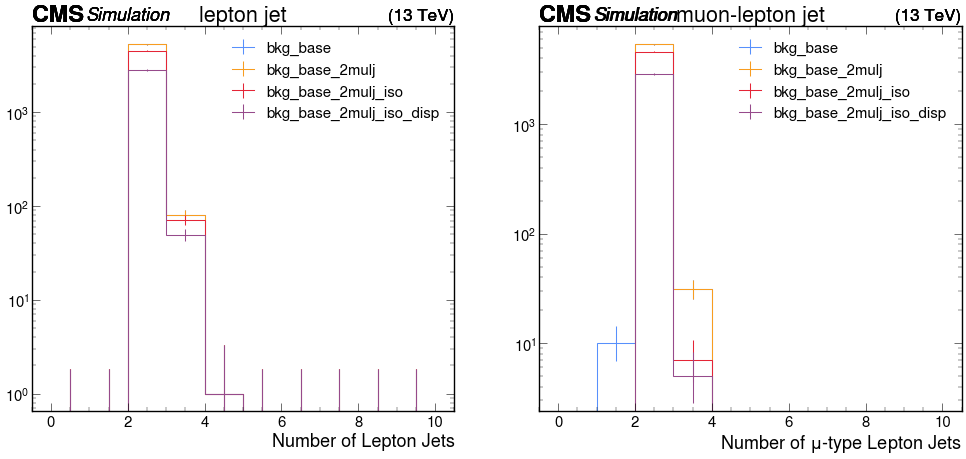

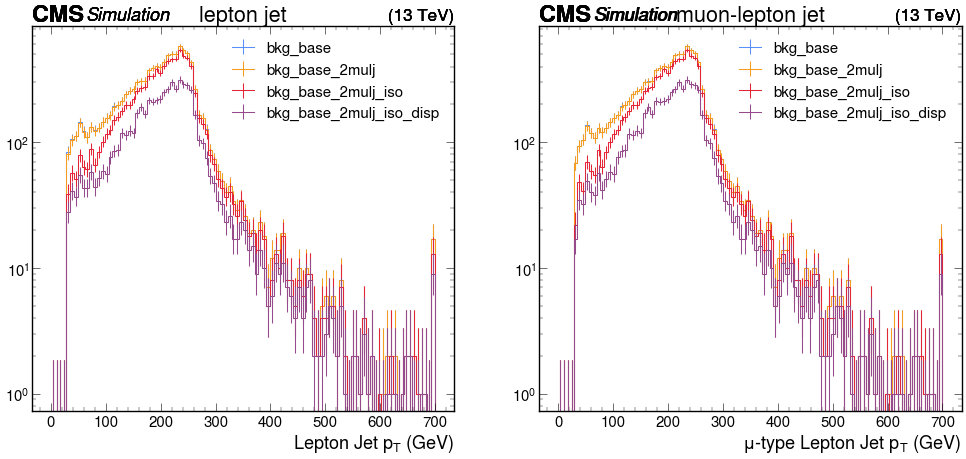

In [71]:
htoplot = ["lj_mass"]
# mutoplot = ["mu_lj_n", "mu_lj_pt"]

for ih, htp in enumerate(htoplot):
    plt.subplots(1, 2, figsize=(24, 10))
    for ch in chan:
        plt.subplot(1, 2, 1)
        utilities.plot(output[sss]["hists"][ljtoplot[ih]][ch, :], label=ch)
        plt.title("lepton jet")
        plt.yscale("log")
        plt.legend()

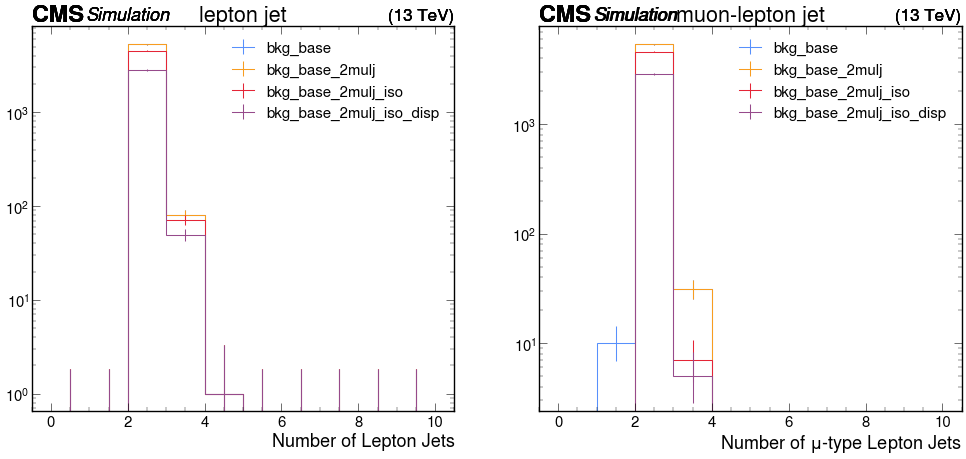

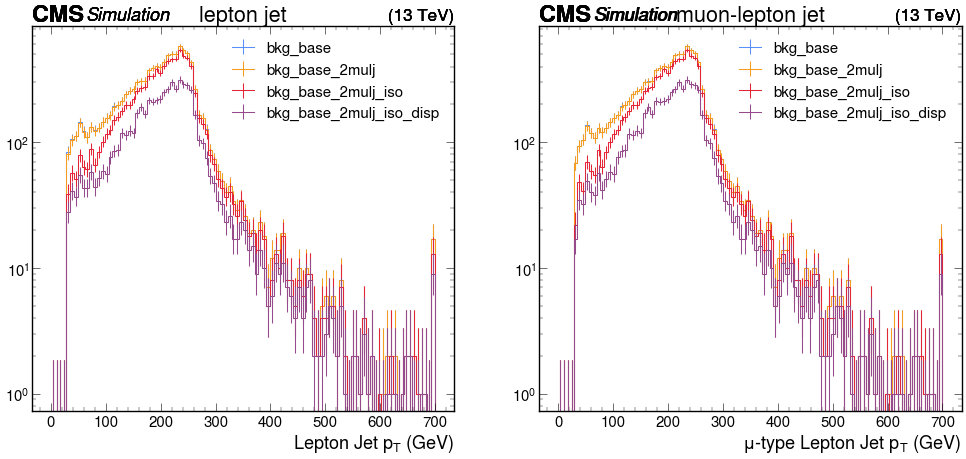

In [71]:
ljtoplot = ["lj_n", "lj_pt"]
mutoplot = ["mu_lj_n", "mu_lj_pt"]

for ih, htp in enumerate(htoplot):
    plt.subplots(1, 2, figsize=(24, 10))
    for ch in chan:
        plt.subplot(1, 2, 1)
        utilities.plot(output[sss]["hists"][ljtoplot[ih]][ch, :], label=ch)
        plt.title("lepton jet")
        plt.yscale("log")
        plt.legend()
        
        plt.subplot(1, 2, 2)
        utilities.plot(output[sss]["hists"][mutoplot[ih]][ch, :], label=ch)
        plt.title("muon-lepton jet")
        plt.yscale("log")
        plt.legend()

lj_n
lj_pt
lj_n
lj_pt
lj_n
lj_pt
lj_n
lj_pt


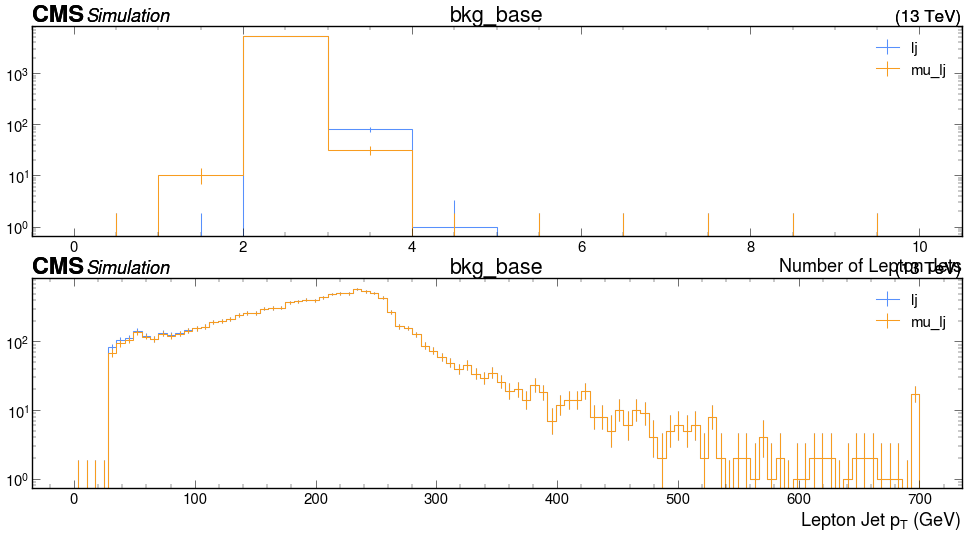

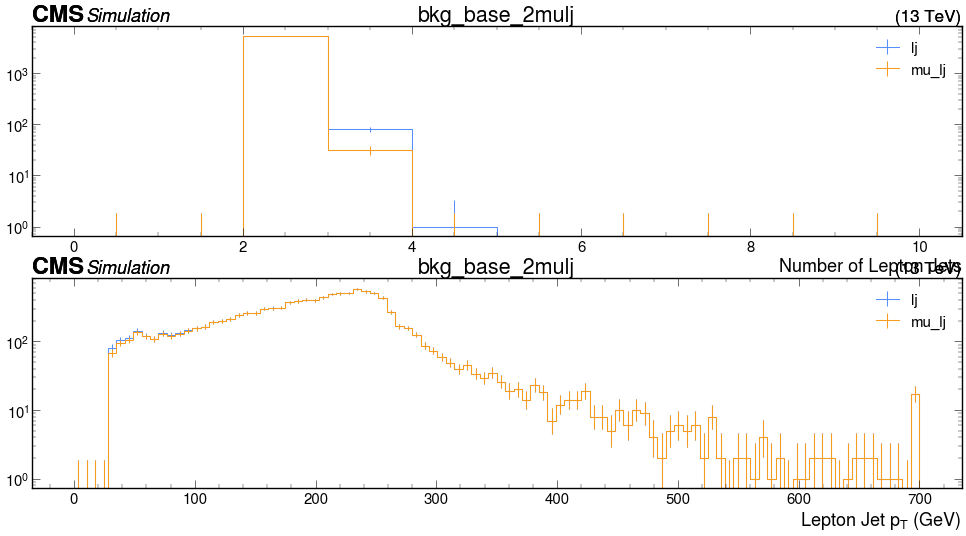

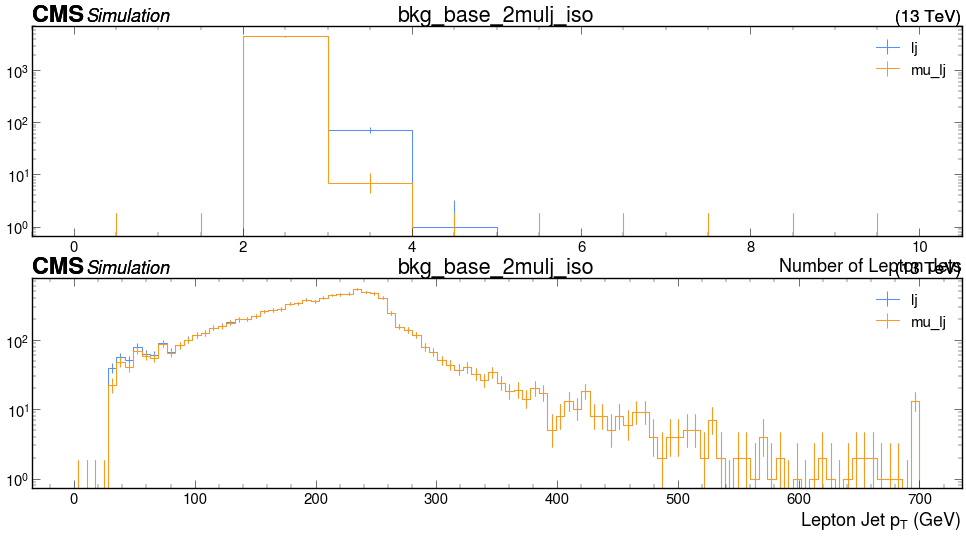

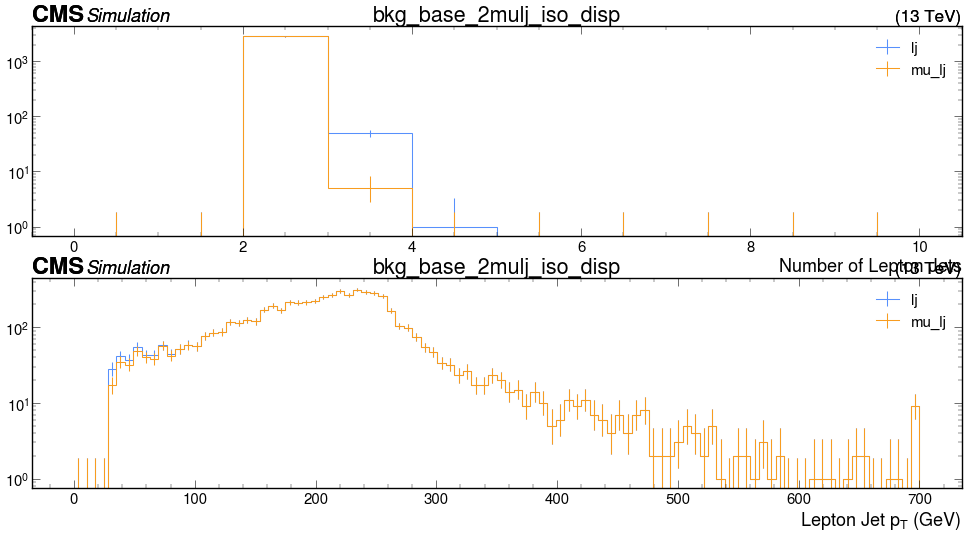

In [60]:
# npl = 4
# xpl, ypl = 2, 1
# htoplot = ["lj_n", "lj_pt"]
# muhtoplot = ["mu_lj_n", "mu_lj_pt"]

# for ch in chan:
# # for ih, htp in enumerate(htoplot):
#     plt.subplots(xpl, ypl, figsize=(xpl*12, ypl*12))
#     for ih, htp in enumerate(htoplot):
#     # for ch in chan:
#         plt.subplot(xpl, ypl, ih+1)
#         print(htoplot[ih])
#         utilities.plot(output[sss]["hists"][htoplot[ih]][ch, :], label="lj")
#         utilities.plot(output[sss]["hists"][muhtoplot[ih]][ch, :], label="mu_lj")
#         # plt.xlabel("$p_T$ [GeV]")
#         # utilities.plot(output["TTJets"]["hists"]["mu_lj_n"][ch1, :], label="mu_lj_n")
#         plt.yscale("log")
#         plt.title(ch)
#         plt.legend()
        
        # plt.subplot(xpl, ypl, 2)
        # utilities.plot(output[sss]["hists"]["lj_pt"][ch2, :], label="lj")
        # utilities.plot(output[sss]["hists"]["mu_lj_pt"][ch2, :], label="mu_lj")
        # # plt.xlabel("$p_T$ [GeV]")
        # plt.yscale("log")
        # plt.title(">1 mu_lj")
        # plt.legend()
    
        # plt.subplot(xpl, ypl, 3)
        # utilities.plot(output[sss]["hists"]["lj_pt"][ch3, :], label="lj")
        # utilities.plot(output[sss]["hists"]["mu_lj_pt"][ch3, :], label="mu_lj")
        # # plt.xlabel("$p_T$ [GeV]")
        # plt.yscale("log")
        # plt.title("Iso")
        # plt.legend()
    
        # plt.subplot(xpl, ypl, 4)
        # utilities.plot(output[sss]["hists"]["lj_pt"][ch4, :], label="lj")
        # utilities.plot(output[sss]["hists"]["mu_lj_pt"][ch4, :], label="mu_lj")
        # # plt.xlabel("$p_T$ [GeV]")
        # plt.yscale("log")
        # plt.title("Disp")
        # plt.legend()
    
        # plt.subplot(xpl, ypl, 5)
        # utilities.plot(output[sss]["hists"]["lj_pt"][ch5, :], label="lj")
        # utilities.plot(output[sss]["hists"]["mu_lj_pt"][ch5, :], label="mu_lj")
        # # plt.xlabel("$p_T$ [GeV]")
        # plt.yscale("log")
        # plt.title(r"$\Delta \Phi$")
        # plt.legend()

In [8]:
ch = channels[-1]
for i in signal:
    print(i)
    output[i]["cutflow"][ch].print_table()
    print()
output["TTJets"]["cutflow"][ch].print_table()

4Mu_500GeV_5p0GeV_8p0mm
cut name              raw N    weighted N    weighted %
------------------  -------  ------------  ------------
None                 6754.0          75.6         100.0
pass triggers        6132.0          68.7          90.8
PV filter            6132.0          68.7          90.8
>=2 LJs              5401.0          60.5          80.0
> 1 mu_lj            2874.0          32.2          42.6
muLJ-muLJ dPhi > 2   2848.0          31.9          42.2

cut name              raw N    weighted N    weighted %
------------------  -------  ------------  ------------
None                21230.0     7751378.5         100.0
pass triggers        1344.0      490713.7           6.3
PV filter            1344.0      490713.7           6.3
>=2 LJs               753.0      274931.1           3.5
> 1 mu_lj               3.0        1095.3           0.0
muLJ-muLJ dPhi > 2      0.0           0.0           0.0


In [9]:
para aqui

SyntaxError: invalid syntax (3767280655.py, line 1)

# Combine files for background

In [ ]:
# combine coffea files into a single files for 50 files run 32d
outall = {}
bkgprocess = [
    "ttj",
    "dyj1",    "dyj2",
    "qcd1",    "qcd2",
    "qcd3",    "qcd4",
    "qcd5",    "qcd6",
    "qcd7",    "qcd8",
    "qcd9",    "qcd10",
    "qcd11",   "qcd12"]

sigprocess = [
    "4Mu500_0p25",
    "4Mu500_1p2",
    "4Mu500_5p0",
    
    "4Mu800_0p25",
    "4Mu800_1p2",
    "4Mu800_5p0",
    
    "4Mu1000_0p25",    
    "4Mu1000_1p2",
    "4Mu1000_5p0",
]

outall = {}
for p in bkgprocess:
    outp = coffea.util.load(f"outputs/bkg_32c_{p}.coffea")
    # if outp:
    #     print(f"outputs/bkg_32c_{p}.coffea")
    outall |= outp
    
for pp in sigprocess:
    outp = coffea.util.load(f"outputs/bkg_32d_{pp}.coffea")
    # if outp:
    #     print(f"outputs/bkg_32d_{pp}.coffea")
    outall |= outp

for k in outall:
    print(k)
    
coffea.util.save(outall, f"outputs/bkg_32d.coffea")

In [ ]:
para mijo

In [ ]:
# output = coffea.util.load("outputs/bkg_32d.coffea")
# for k in output:
#     print(k)

# Testing lj mass difference on siganl and background

In [ ]:
vr = "33"
nfiles = 1
samples4mu = [fmulxy6[2]]
samples2mu = [tmulxy6[2]]
print(samples4mu, samples2mu)
channels = ["bkg_base_2mulj",
            # "bkg_base_2mulj_iso",
            "bkg_base_2mulj_iso_disp",
            # "bkg_base_2mulj_iso_disp_dphi",
            # "bkg_base_2mulj_iso_disp_dphi_mass150",
            # "bkg_base_2mulj_iso_disp_dphi_mass175",
            "bkg_base_1mu1egmlj",
            "bkg_base_1mu1egmlj_iso_disp",
            
           ]

ch1 = channels[0]
ch2 = channels[1]
ch3 = channels[2]
ch4 = channels[3]
# ch5 = channels[4]
# ch6 = channels[5]

cha = [ch1, ch2, ch3, ch4]
figh, figw = 12, 10

In [ ]:
runner = processor.Runner(
    # executor=processor.DaskExecutor(client=client),      # for dask
    executor=processor.FuturesExecutor(),              # for testing locally
    # executor=processor.IterativeExecutor(),              # for testing locally
    schema = llpnanoaodschema.LLPNanoAODSchema,
    chunksize=2000,
    maxchunks=1,
    skipbadfiles=True,
)

p = sidm_processor.SidmProcessor(    channels,    ["BKG_study"],    unweighted_hist=True, verbose=False)

In [ ]:
fileset = utilities.make_fileset(samples4mu, "llpNanoAOD_v2", max_files = nfiles, location_cfg="signal_4mu_v10.yaml")
out = runner.run(fileset, treename="Events", processor_instance=p)
out4 = out["out"]
# coffea.util.save(out, "outputs/bkg_test"+ vr + "_fmu.coffea")

In [ ]:
# process 2mu2e
fileset = utilities.make_fileset(samples2mu, "llpNanoAOD_v2", max_files = nfiles, location_cfg="signal_2mu2e_v10.yaml")
out     = runner.run(fileset, treename="Events", processor_instance=p)
out2    = out["out"]
# coffea.util.save(out21, "outputs/bkg_" + vr + "_tmu1.coffea")

In [ ]:
out = {
    **out2, 
    **out4,
#     **outdyj,
#     **outttj,
#     **outqcd, 
#     **outocd,
}
coffea.util.save(out, f"outputs/bkg_test_{vr}.coffea")
for k in out:
    print(k)

In [ ]:
for sss in samples2mu:
    utilities.plot(out[sss]["hists"]["pf_mulj_egmlj_invmass"][ch1, :], label="mulj_lead",)
    # utilities.plot(out[sss]["hists"]["mulj2_mass"][ch1, :], label="mulj_sub",  ax=axs[0, 0], )

In [ ]:
npl = 2
fig, axs = plt.subplots(2, 2, figsize=(20, 16))

for sss in samples4mu:
    utilities.plot(out[sss]["hists"]["mulj1_mass"][ch1, :], label="mulj_lead", ax=axs[0, 0])
    utilities.plot(out[sss]["hists"]["mulj2_mass"][ch1, :], label="mulj_sub",  ax=axs[0, 0], )

axs[0, 0].set_ylabel("Events")
axs[0, 0].set_yscale("log")
axs[0, 0].legend(title="lxy [cm]", alignment="left", loc=0)

utilities.plot(out[sss]["hists"]["muljs_massdiff"][ch1, :], label="mulj1-mulj2", ax=axs[0, 1])
axs[0, 1].set_ylabel("Events")
axs[0, 1].set_yscale("log")
axs[0, 1].legend(title="lxy [cm]", alignment="left", loc=0)

for sss in samples2mu:
    utilities.plot(out[sss]["hists"]["mulj_invmass"][ch3, :], label="mulj", ax=axs[1, 0])
    utilities.plot(out[sss]["hists"]["egmlj_invmass"][ch3, :],label="egmlj", ax=axs[1, 0])

axs[1, 0].set_ylabel("Events")
axs[1, 0].set_yscale("log")
axs[1, 0].legend(title="lxy [cm]", alignment="left", loc=0)

utilities.plot(out[sss]["hists"]["muegmljs_massdiff"][ch3, :], label="egmlj-mulj", ax=axs[1, 1])
axs[1, 1].set_ylabel("Events")
axs[1, 1].set_yscale("log")

In [ ]:
Vamos mijo

## Testing individual mlj masses 

In [ ]:
vr = "32b"
nfiles = 3
samples = ["4Mu_500GeV_1p2GeV_1p9mm", "4Mu_500GeV_1p2GeV_9p6mm", "4Mu_500GeV_1p2GeV_19p0mm",]

channels = ["bkg_base_2mulj",
            "bkg_base_2mulj_iso",
            "bkg_base_2mulj_iso_disp",
            "bkg_base_2mulj_iso_disp_dphi",
            "bkg_base_2mulj_iso_disp_dphi_mass150",
            "bkg_base_2mulj_iso_disp_dphi_mass175",]

ch1 = channels[0]
ch2 = channels[1]
ch3 = channels[2]
ch4 = channels[3]
ch5 = channels[4]
ch6 = channels[5]

cha = [ch1, ch2, ch3, ch4, ch5, ch6]
figh, figw = 12, 10

In [ ]:
runner = processor.Runner(
    # executor=processor.DaskExecutor(client=client),      # for dask
    executor=processor.FuturesExecutor(),              # for testing locally
    # executor=processor.IterativeExecutor(),              # for testing locally
    schema = llpnanoaodschema.LLPNanoAODSchema,
    chunksize=2000,
    # maxchunks=2,
    skipbadfiles=True,
)

p = sidm_processor.SidmProcessor(    channels,    ["BKG_study"],    unweighted_hist=True, verbose=False)

In [ ]:
fileset = utilities.make_fileset(samples, "llpNanoAOD_v2", max_files = nfiles, location_cfg="signal_4mu_v10.yaml")
out = runner.run(fileset, treename="Events", processor_instance=p)
out = out["out"]
# coffea.util.save(out41, "outputs/bkg_test"+ vr + "_fmu1.coffea")

In [ ]:
npl = 3
cht = ch1
for cht in cha:
    plt.subplots(1, npl, figsize=(npl*figw, figh))
    for ix, sss in enumerate(samples):
        plt.subplot(1, npl, 1)
        utilities.plot(out[sss]["hists"]["mulj1_mass"][cht, :], label = sss)
        plt.ylabel("Events")
        plt.yscale("log")
        plt.legend(title="lxy [cm]", alignment="left", loc=0)
        
        plt.subplot(1, npl, 2)
        # utilities.plot(output[sss]["hists"]["mulj1_mass"][cht, :], label = r"$\mu$LJ1")
        utilities.plot(out[sss]["hists"]["mulj2_mass"][cht, :], label = sss)
        # utilities.plot(output[sss]["hists"]["mulj_mulj_invmass"][ch1, :], label = lablxy1[ix])
        plt.ylabel("Events")
        plt.yscale("log")
        # plt.title(sss)
        plt.legend(title="lxy [cm]", alignment="left", loc=0)
    
        plt.subplot(1, npl, 3)
        utilities.plot(out[sss]["hists"]["muljs_massdiff"][cht, :], label = sss)
        # utilities.plot(output[sss]["hists"]["mulj2_mass"][ch1, :])
        # utilities.plot(output[sss]["hists"]["mulj_mulj_invmass"][ch1, :], label = lablxy1[ix])
        plt.ylabel("Events")
        plt.yscale("log")
        plt.legend(title="lxy [cm]", alignment="left", loc=0)
    plt.title(cht)

In [ ]:
vamos mijo

In [ ]:
vr = "28"
nfiles = -1
sig2mu = [
    "2Mu2E_500GeV_0p25GeV_4p0mm", #changing MZd
    "2Mu2E_500GeV_1p2GeV_19p0mm",
     "2Mu2E_800GeV_5p0GeV_50p0mm",    
]

sig4mu = [
    "4Mu_500GeV_0p25GeV_0p004mm",
    "4Mu_500GeV_1p2GeV_19p0mm",
    "4Mu_500GeV_5p0GeV_80p0mm",
]

channels = [
    # "baseNoLj",
    # "base_ljObjCut",
    "bkg_iso_disp_2lj_4mu_dphi",
    "bkg_iso_disp_2lj_2mu2e_dphi",
    # "bkg_iso_disp_2lj_4mu_dphi_ljmd",
    # "bkg_iso_disp_2lj_4mu_dphi_ljmd_mjj150",
]

ch1 = channels[0] # base
ch2 = channels[1] # base 2
# ch3 = channels[2] # 4mu
# ch4 = channels[3] # mdiff < 0.1
# ch5 = channels[4] # mjj cut 150

bkgdyj = [
    "DYJetsToMuMu_M10to50",
    "DYJetsToMuMu_M50",
]
bkgttj = ["TTJets"]

bkgqcd = [
    "QCD_Pt15To20",
    "QCD_Pt20To30",
    "QCD_Pt30To50",
    "QCD_Pt50To80",
    "QCD_Pt80To120",
]

bkgocd = [
    "QCD_Pt120To170",
    "QCD_Pt170To300",
    "QCD_Pt300To470",
    "QCD_Pt470To600",
    "QCD_Pt600To800",
    "QCD_Pt800To1000", 
    "QCD_Pt1000",       
]

In [ ]:
runner = processor.Runner(
    executor=processor.FuturesExecutor(),                # for testing locally
    # executor=processor.IterativeExecutor(),            # for testing locally
    schema = llpnanoaodschema.LLPNanoAODSchema,
    skipbadfiles=True,
)

p = sidm_processor.SidmProcessor(
    channels,
    ["BKG_study"],
    unweighted_hist=True, verbose=False
)

In [ ]:
# process 2mu2e
fileset2mu = utilities.make_fileset(sig2mu, "llpNanoAOD_v2", max_files = nfiles, location_cfg="signal_2mu2e_v10.yaml")
out2mu = runner.run(fileset2mu, treename="Events", processor_instance=p)
out2mu = out2mu["out"]
coffea.util.save(out2mu, "outputs/bkg_" + vr + "_2mu.coffea")

In [ ]:
#process 4mu
fileset4mu = utilities.make_fileset(sig4mu, "llpNanoAOD_v2", max_files = nfiles, location_cfg="signal_4mu_v10.yaml")
out4mu = runner.run(fileset4mu, treename="Events", processor_instance=p)
out4mu = out4mu["out"]
coffea.util.save(out4mu, "outputs/bkg_" + vr + "_4mu.coffea")

In [ ]:
# htplot = ["mulj1Mass"]
out2 = coffea.util.load("outputs/bkg_28_2mu.coffea")
out4 = coffea.util.load("outputs/bkg_28_4mu.coffea")

output = {**out2, **out4}

cha = ch2
npl = 2
# ss2 = sig2mu[0]
# ss4 = sig4mu[0]
mzd = ["0.25", "1.2", "5.0"]
###################
#### 2mu  ########
###################
plt.subplots(1, npl, figsize=(npl*16, 10))
plt.subplot(1,2,1)
for im, ss2 in enumerate(sig2mu):
    utilities.plot(output[ss2]["hists"]["lj0_mass"][cha, :], label = f"Leading {mzd[im]}")
    utilities.plot(output[ss2]["hists"]["lj1_mass"][cha, :], label = f"subLeading {mzd[im]}")
plt.title("2mu")
plt.yscale("log")
plt.legend(title=r"lepton jet - $Z_D$ mass [GeV] ", alignment="left", loc=0)

plt.subplot(1,2,2)
for im, ss2 in enumerate(sig2mu):
    utilities.plot(output[ss2]["hists"]["lj_mass_diff"][cha, :], label = mzd[im])
plt.title("2mu")
plt.yscale("log")
plt.legend(title=r"$Z_D$ mass [GeV]", alignment="left", loc=0)

###################
#### 4mu  ########
###################

cha = ch1
plt.subplots(1, npl, figsize=(npl*16, 10))
plt.subplot(1,2,1)
for im, ss4 in enumerate(sig4mu):
    utilities.plot(output[ss4]["hists"]["lj0_mass"][cha, :], label = f"Leading {mzd[im]}")
    utilities.plot(output[ss4]["hists"]["lj1_mass"][cha, :], label = f"subleading {mzd[im]}")
plt.title("4mu")
plt.yscale("log")
plt.legend(title=r"lepton jet - $Z_D$ mass [GeV] ", alignment="left", loc=0)

plt.subplot(1,2,2)
for im, ss4 in enumerate(sig4mu):
    utilities.plot(output[ss4]["hists"]["lj_mass_diff"][cha, :], label = mzd[im])
plt.title("4mu")
plt.yscale("log")
plt.legend(title=r"$Z_D$ mass [GeV]", alignment="left", loc=0)

In [ ]:
# htplot = ["mulj1Mass"]
out2 = coffea.util.load("outputs/bkg_28_2mu.coffea")
out4 = coffea.util.load("outputs/bkg_28_4mu.coffea")

output = {**out2, **out4}

cha = ch2
npl = 2
# ss2 = sig2mu[0]
# ss4 = sig4mu[0]
mzd = ["0.25", "1.2", "5.0"]
###################
#### 2mu  ########
###################
plt.subplots(1, npl, figsize=(npl*16, 10))
plt.subplot(1,2,1)
for im, ss2 in enumerate(sig2mu):
    utilities.plot(output[ss2]["hists"]["lj0_mass"][cha, :], label = f"Leading {mzd[im]}")
    utilities.plot(output[ss2]["hists"]["lj1_mass"][cha, :], label = f"subLeading {mzd[im]}")
plt.title("2mu")
plt.yscale("log")
plt.legend(title=r"lepton jet - $Z_D$ mass [GeV] ", alignment="left", loc=0)



###################
#### 4mu  ########
###################

cha = ch1
# plt.subplots(1, npl, figsize=(npl*16, 10))
plt.subplot(1,2,2)
for im, ss4 in enumerate(sig4mu):
    utilities.plot(output[ss4]["hists"]["lj0_mass"][cha, :], label = f"Leading {mzd[im]}")
    utilities.plot(output[ss4]["hists"]["lj1_mass"][cha, :], label = f"subleading {mzd[im]}")
plt.title("4mu")
plt.yscale("log")
plt.legend(title=r"lepton jet - $Z_D$ mass [GeV] ", alignment="left", loc=0)
plt.savefig(f"clean_plots/ljmass.png", bbox_inches="tight", dpi=300)

In [ ]:
# process DYJ
# filesetdyj = utilities.make_fileset(bkgdyj, "skimmed_llpNanoAOD_v2", max_files = nfiles, location_cfg = "backgrounds.yaml",)
# outdyj     = runner.run(filesetdyj, treename="Events", processor_instance=p)
# outdyj     = outdyj["out"]

In [ ]:
# Process ttj
filesetttj = utilities.make_fileset(bkgttj, "skimmed_llpNanoAOD_v2", max_files = nfiles, location_cfg = "backgrounds.yaml",)
outttj     = runner.run(filesetttj, treename="Events", processor_instance=p)
outttj     = outttj["out"]
coffea.util.save(outttj, "outputs/bkg_" + vr + "_ttj.coffea")

In [ ]:
# process qcd
# filesetqcd    = utilities.make_fileset(bkgqcd, "skimmed_llpNanoAOD_v2", max_files = nfiles, location_cfg = "backgrounds.yaml",)
# outqcd        = runner.run(filesetqcd, treename="Events", processor_instance=p)
# outqcd        = outqcd["out"]

In [ ]:
# process ocd
filesetocd    = utilities.make_fileset(bkgocd, "skimmed_llpNanoAOD_v2", max_files = nfiles, location_cfg = "backgrounds.yaml",)
outocd        = runner.run(filesetocd, treename="Events", processor_instance=p)
outocd        = outocd["out"]
coffea.util.save(outocd, "outputs/bkg_" + vr + "_ocd.coffea")

In [ ]:
# outall = {
#     # **out2mu, 
#     **out4mu,
#     # **outdyj,
#     # **outttj,
#     # **outqcd, 
#     # **outocd,
# }

# File 28
## test ljmass difference

In [ ]:
# htplot = ["mulj1Mass"]
output = coffea.util.load("outputs/bkg_28_4mu.coffea")
outocd = coffea.util.load("outputs/bkg_28_ocd.coffea")
cha = ch3

plt.subplots(1, 2, figsize=(32, 10))
plt.subplot(1,2,1)
# for ij, sss in enumerate(mxx2):
# utilities.plot(output[sig4mu[0]]["hists"]["mulj1Mass"][cha, :], label = "Lead")
# utilities.plot(output[sig4mu[0]]["hists"]["mulj2Mass"][cha, :], label = "sLead")
# utilities.plot(output[sig4mu[0]]["hists"]["lje_invmass"][cha, :], label = "Ele")
utilities.plot(output[sig4mu[0]]["hists"]["ljm_invmass"][cha, :], label = "Muon")
utilities.plot(output[sig4mu[0]]["hists"]["ljm_invmass"][cha, :], label = "Muon")

plt.title("Muon Lj mass")
plt.ylabel("Events")
plt.yscale("log")
plt.legend(title=r"$\mu$-type", alignment="left", loc=0)

plt.subplot(1,2,2)
utilities.plot(output[sig4mu[0]]["hists"]["muljs_Massdiff"][cha, :], label = r"sig")   #r"|m_{lj1} - m_{lj2}|")
plt.title("Muon Ljs mass diff")
plt.ylabel("Events")
plt.yscale("log")
plt.legend(title=r"$\mu$-type", alignment="left", loc=0)

# plt.savefig(f"clean_plots/fin_28_ljmass_4mu.pdf", bbox_inches="tight", dpi=300)

# test mass cut on invmass BS

In [ ]:

# htplot = ["mulj1Mass"]
output = coffea.util.load("outputs/bkg_28_4mu.coffea")
outocd = coffea.util.load("outputs/bkg_28_ocd.coffea")
cha = [ch1, ch3, ch4, ch5]
chaname = ["base", r"$4\mu$", r"mass diff", r"$m_{jj}>150$"]
npl = 2

plt.subplots(1, npl, figsize=(16*npl, 10))
plt.subplot(1,2,1)
for ij, ch in enumerate(cha):
    utilities.plot(output[sig4mu[0]]["hists"]["lj_lj_invmass"][ch, :], label = chaname[ij])
    plt.title("LJ_LJ inv mass")
    plt.ylabel("Events")
    plt.yscale("log")
    plt.legend(title=r"Selection", alignment="left", loc=1)

# OCD = merge_samples(outocd, bkgocd, "lj_lj_invmass", ch)

plt.subplot(1,2,2)
for ij, ch in enumerate(cha):
    OCD = merge_samples(outocd, bkgocd, "lj_lj_invmass", ch)
    utilities.plot(OCD, label=chaname[ij])
    # TTJ = merge_samples(outttj, bkgttj, "lj_lj_invmass", ch)
    # utilities.plot(OCD, label=ch,)
    # utilities.plot(output[sig4mu[0]]["hists"]["lj_lj_invmass"][ch5, :], label = ch)
    plt.title("LJ_LJ inv mass")
    plt.ylabel("Events")
    plt.yscale("log")
    plt.legend(title=r"Selection", alignment="left", loc=0)

# plt.savefig(f"clean_plots/fin_{26}_muonRes_2mu.pdf", bbox_inches="tight", dpi=300)

In [ ]:
outocd

In [ ]:
ht = "lj_lj_invmass"
cha2name = ["Base", "Iso", "Disp", r"2mu2e", r"$\Delta\Phi > 2$"]
cha2 = [ch1, ch2, ch3, ch5,]

for ic, ch in enumerate(cha2):
    
    fig, ax = plt.subplots(figsize=(16,10))
    
    # DYJ = merge_samples(output, bkgdyj, ht, ch)
    QCD = merge_samples(output, bkgocd, ht, ch)
    TTJ = merge_samples(output, bkgttj, ht, ch)
    
    # Backgrounds stacked
    hep.histplot([QCD, TTJ],     stack=True,     histtype="fill",     color=["green", "red"],     label=["QCD", "TTJ"],     ax=ax,)
    
    # Signal overlaid
    colmx=["black", "darkviolet", "navy", "magenta", "darkorange", "darkblue"]
    labmx=[r"$2\mu2e: m_{xx}=200$", r"$2\mu2e: m_{xx}=500$", r"$2\mu2e: m_{xx}=800$", r"$2\mu2e: m_{xx}=1000$"]
    hep.histplot(output[sig4mu[0]]["hists"]["lj_lj_invmass"][ch, :], 
                     color=colmx[ix], 
                     label=labmx[ix], 
                     histtype="step", 
                     linewidth=3, 
                     ax=ax
                    )
    # for ix, sss in enumerate(mxx2):
    #     hep.histplot(output[sss]["hists"][ht][ch1, ::2j], 
    #                  color=colmx[ix], 
    #                  label=labmx[ix], 
    #                  histtype="step", 
    #                  linewidth=3, 
    #                  ax=ax
    #                 )
    hep.cms.label(data=False,
    lumi=None,
    com=13,
    ax=ax,
    )
    ax.set_ylim(1, 1000000)
    # ax.yscale(1,10000)
    ax.set_yscale("log")
    ax.legend(title="Process", ncol=2)
    plt.title(f"selection: {cha2name[ic]}")
    # plt.show()
    # plt.savefig(f"clean_plots/fin_bkg_stack_{vr}_{ht}_{cha2name[ic]}_mxx.pdf", bbox_inches="tight", dpi=300)

In [ ]:
plt.subplots(1, 1, figsize=(16, 10))
plt.subplot(1,2,1)
utilities.plot(outall[sig4mu[0]]["hists"]["lj_lj_invmass"][ch2, :], label = sig4mu[0])
# utilities.plot(outall[sig4mu[0]]["hists"]["lj_lj_invmass"][ch1, :], label = "lj2")
utilities.plot(outall[bkgdyj[0]]["hists"]["lj_lj_invmass"][ch2, :], label = "dyj")
utilities.plot(outall[bkgttj[0]]["hists"]["lj_lj_invmass"][ch2, :], label = "ttj")

plt.yscale("log")
plt.title("-")
plt.legend()

plt.subplot(1,2,2)
utilities.plot(outall[sig4mu[0]]["hists"]["lj_lj_invmass"][ch3, :], label = sig4mu[0])
# utilities.plot(outall[sig4mu[0]]["hists"]["lj_lj_invmass"][ch1, :], label = "lj2")
utilities.plot(outall[bkgdyj[0]]["hists"]["lj_lj_invmass"][ch3, :], label = "dyj")
utilities.plot(outall[bkgttj[0]]["hists"]["lj_lj_invmass"][ch3, :], label = "ttj")

plt.yscale("log")
plt.title("-")
plt.legend()

In [ ]:
plt.subplots(1, 2, figsize=(32, 10))
plt.subplot(1,2,1)
utilities.plot(out4mu[sig4mu[0]]["hists"]["mulj1Mass"][ch1, :], label = "lj1")
utilities.plot(out4mu[sig4mu[0]]["hists"]["mulj2Mass"][ch1, :], label = "lj2")
plt.yscale("log")
plt.title(sig4mu[0])
plt.legend()

plt.subplot(1, 2, 2)
utilities.plot(out4mu[sig4mu[0]]["hists"]["mulj1Mass"][ch2, :], label = "lj1")
utilities.plot(out4mu[sig4mu[0]]["hists"]["mulj2Mass"][ch2, :], label = "lj2")
plt.yscale("log")
plt.title(sig4mu[0])
plt.legend()
# plt.savefig(f"clean_plots/fin_mass.pdf", bbox_inches="tight", dpi=300)

In [ ]:
plt.subplots(1, 2, figsize=(32, 10))
plt.subplot(1,2,1)
utilities.plot(out4mu[sig4mu[0]]["hists"]["muljs_Massdiff"][ch1, ::2j], label = "No cut")
plt.yscale("log")
plt.title(sig4mu[0])
plt.legend()

plt.subplot(1, 2, 2)
utilities.plot(out4mu[sig4mu[0]]["hists"]["muljs_Massdiff"][ch2, ::2j], label = r"$\Delta(m1, m2) < 0.1$")
plt.yscale("log")
plt.title(sig4mu[0])
plt.legend()
# plt.savefig(f"clean_plots/fin_mass_diff.pdf", bbox_inches="tight", dpi=300)

In [ ]:
plt.subplots(1, 1, figsize=(16, 10))
# plt.subplot(1,2,1)
utilities.plot(out4mu[sig4mu[0]]["hists"]["lj_lj_invmass"][ch1, ::2j], label = "No cut")
utilities.plot(out4mu[sig4mu[0]]["hists"]["lj_lj_invmass"][ch2, ::2j], label = "4mu")
utilities.plot(out4mu[sig4mu[0]]["hists"]["lj_lj_invmass"][ch3, ::2j], label = r"$\Delta(m1, m2) < 0.1$")
plt.yscale("log")
plt.title(sig4mu[0])
plt.legend()

# plt.subplots(1, 2, figsize=(32, 10))
# plt.subplot(1,2,1)
# utilities.plot(out4mu[sig4mu[0]]["hists"]["lj_lj_invmass"][ch2, ::2j], label = "No cut")
# plt.yscale("log")
# plt.title(sig4mu[0])
# plt.legend()

# plt.subplot(1, 2, 2)
# utilities.plot(out4mu[sig4mu[0]]["hists"]["muljs_Massdiff"][ch2, ::2j], label = r"$\Delta(m1, m2) < 0.1$")
# plt.yscale("log")
# plt.title(sig4mu[0])
# plt.legend()
# plt.savefig(f"clean_plots/fin_mass_diff.pdf", bbox_inches="tight", dpi=300)

In [ ]:
plt.subplots(1, 1, figsize=(16, 10))
# utilities.plot(out2mu[sig2mu[0]]["hists"]["muon_muon_dR"][ch1, ::3j], label = "dR")
utilities.plot(out2mu[sig2mu[0]]["hists"]["muon_muon_dR2"][ch1, ::3j], label = "dR2")

In [ ]:
plt.subplots(1, 1, figsize=(16, 10))
# utilities.plot(out2mu[sig2mu[0]]["hists"]["muon_muon_dR"][ch1, ::3j], label = "dR")
utilities.plot(out2mu[sig2mu[0]]["hists"]["muon_genMu_matched_dR"][ch1, ::3j], label = "dR2")

In [ ]:
plt.subplots(1, 1, figsize=(16, 10))
utilities.plot(out2mu[sig2mu[0]]["hists"]["muon_pt_resolution"][ch1, :], label = "PF")
utilities.plot(out2mu[sig2mu[0]]["hists"]["dsaMuon_pt_resolution"][ch1, :], label = "DSA")
plt.legend()

In [ ]:
h = out2mu[sig2mu[0]]["hists"]["lj_eta_phi"]
# print(h.axes)

plt.subplots(1, 1, figsize=(16, 10))
utilities.plot(out2mu[sig2mu[0]]["hists"]["lj_eta_phi"][channels[0], ::2j, :].project("ljs_eta"), density=False)

plt.subplots(1, 1, figsize=(16, 10))
utilities.plot(out2mu[sig2mu[0]]["hists"]["lj_eta_phi"][channels[0], ::2j, :].project("ljs_phi"), density=False)